#### Crearea seturilor inițiale de antrenare/testare

In [114]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

# Se citesc datele originale
df = pd.read_csv('../raw_data.csv', low_memory=False)

# Se creeaza coloane separate pentru length si width din coloana measurement_type
df = pd.get_dummies(df, columns=['measurement_type'], dtype=float)
df.insert(loc=3, column='length', value=df['measurement_type_length'])
df.insert(loc=4, column='width', value=df['measurement_type_width'])

# Se muta valorile average ale masuratorilor in coloanele cu length si width
df['length'] = df['length'] * df['average']
df['width'] = df['width'] * df['average']

# Se elimina coloanele redundante
df = df.drop(df.filter(regex='measurement_type_'), axis=1)
df = df.drop('average', axis=1)

# Se pastreaza doar randurile pentru care se cunoaste specia
df = df[df['accepted_rank'] == 'species']

# Se combina randurile pentru acelasi specimen care au masuratorile length si width separate
aggr_funcs = {'specimen_part' : 'first', 'length' : 'sum', 'width' : 'sum', 'max_ma' : 'first',
              'min_ma' : 'first', 'paleolng' : 'first', 'paleolat' : 'first', 'formation' : 'first',
			  'lithology1' : 'first', 'environment' : 'first','accepted_name' : 'first'}
df = df.groupby(df['specimen_no']).aggregate(aggr_funcs)

# Se curata stringurile
string_fields = ['specimen_part', 'formation', 'lithology1', 'environment', 'accepted_name']

for field in string_fields:
	df[field] = df[field].str.replace('\"', '')
	df[field] = df[field].str.replace(',', '')
	df[field] = df[field].str.replace('?', '')
	df[field] = df[field].str.strip()

# Se imparte in setul de antrenare si setul de testare
train_df, test_df = train_test_split(df, test_size=0.2, random_state=67)

#### Procentul valorilor lipsă

In [115]:
import matplotlib.pyplot as plt
import seaborn as sns

# Se calculeaza procentul valorilor lipsa
train_null = (train_df.isnull().sum(axis = 0) + train_df.isin(['not reported']).sum(axis=0)) / train_df.shape[0] * 100
test_null = (test_df.isnull().sum(axis = 0) + test_df.isin(['not reported']).sum(axis=0)) / test_df.shape[0] * 100

print(train_null, '\n', test_null)


specimen_part     0.056367
length            0.000000
width             0.000000
max_ma           62.786765
min_ma           62.786765
paleolng         66.940984
paleolat         66.940984
formation        72.515642
lithology1       82.593991
environment      62.786765
accepted_name     0.000000
dtype: float64 
 specimen_part     0.067628
length            0.000000
width             0.000000
max_ma           63.142471
min_ma           63.142471
paleolng         67.493237
paleolat         67.493237
formation        72.768260
lithology1       82.596934
environment      63.142471
accepted_name     0.000000
dtype: float64


#### Tratarea valorilor lipsă

In [116]:
# Se elimina randurile cu valori lipsa pentru variabilele importante
train_df = train_df.dropna(subset=['specimen_part', 'max_ma', 'min_ma', 'accepted_name', 'paleolat'])
test_df = test_df.dropna(subset=['specimen_part', 'max_ma', 'min_ma', 'accepted_name', 'paleolat'])

# Valorile lipsa sunt inlocuite cu unknown
train_df[['formation', 'lithology1']] = train_df[['formation', 'lithology1']].fillna('unknown')
test_df[['formation', 'lithology1']] = test_df[['formation', 'lithology1']].fillna('unknown')
train_df['lithology1'] = train_df['lithology1'].str.replace('not reported', 'unknown')
test_df['lithology1'] = test_df['lithology1'].str.replace('not reported', 'unknown')

#### Obținerea seturilor de date

In [117]:
# Se elimina randurile cu valori lipsa pentru variabilele importante
df = df.dropna(subset=['specimen_part', 'max_ma', 'min_ma', 'accepted_name', 'paleolat'])

# Se elimina speciile care apar doar o data
species_counts = df['accepted_name'].value_counts()
valid_species = species_counts[species_counts > 1].index
df = df[df['accepted_name'].isin(valid_species)].copy()

# Valorile lipsa sunt inlocuite cu unknown
df[['formation', 'lithology1']] = df[['formation', 'lithology1']].fillna('unknown')
df['lithology1'] = df['lithology1'].str.replace('not reported', 'unknown')

# Se salveaza in format csv
train_df.to_csv('../train_data.csv', index=False)
test_df.to_csv('../test_data.csv', index=False)
df.info()
df.to_csv('../new_data.csv', index=False)

<class 'pandas.DataFrame'>
Index: 6791 entries, 1 to 125208
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   specimen_part  6791 non-null   str    
 1   length         6791 non-null   float64
 2   width          6791 non-null   float64
 3   max_ma         6791 non-null   float64
 4   min_ma         6791 non-null   float64
 5   paleolng       6791 non-null   float64
 6   paleolat       6791 non-null   float64
 7   formation      6791 non-null   str    
 8   lithology1     6791 non-null   str    
 9   environment    6791 non-null   str    
 10  accepted_name  6791 non-null   str    
dtypes: float64(6), str(5)
memory usage: 636.7 KB


#### Statistici

In [46]:
train_df.describe(include='all')

,specimen_part,length,width,max_ma,min_ma,paleolng,paleolat,formation,lithology1,environment,accepted_name
count,5858,5858.000000,5858.000000,5858.000000,5858.00000,5858.000000,5858.000000,5858,5858,5858,5858
unique,476,NaN,NaN,NaN,NaN,NaN,NaN,257,20,37,1409
top,m1,NaN,NaN,NaN,NaN,NaN,NaN,unknown,unknown,terrestrial indet.,Magdalenabradys confusum
freq,1335,NaN,NaN,NaN,NaN,NaN,NaN,1208,3179,4133,148
mean,NaN,21.430786,10.048903,27.921591,24.12730,-82.809473,30.980775,NaN,NaN,NaN,NaN
std,NaN,90.732811,42.393599,21.053452,20.58081,22.609949,25.990285,NaN,NaN,NaN,NaN
min,NaN,0.000000,0.000000,1.400000,0.00000,-169.240000,-69.260000,NaN,NaN,NaN,NaN
25%,NaN,1.752500,1.350000,12.500000,9.40000,-95.790000,9.960000,NaN,NaN,NaN,NaN
50%,NaN,3.890000,2.980000,18.500000,16.30000,-84.140000,39.840000,NaN,NaN,NaN,NaN
75%,NaN,13.865000,8.900000,45.900000,39.70000,-71.590000,49.050000,NaN,NaN,NaN,NaN


In [118]:
test_df.describe(include='all')

,specimen_part,length,width,max_ma,min_ma,paleolng,paleolat,formation,lithology1,environment,accepted_name
count,1440,1440.000000,1440.000000,1440.000000,1440.000000,1440.000000,1440.000000,1440,1440,1440,1440
unique,192,NaN,NaN,NaN,NaN,NaN,NaN,184,21,33,733
top,m1,NaN,NaN,NaN,NaN,NaN,NaN,unknown,unknown,terrestrial indet.,Magdalenabradys confusum
freq,328,NaN,NaN,NaN,NaN,NaN,NaN,296,778,1019,40
mean,NaN,29.874701,12.123906,27.411719,23.644441,-81.493021,30.092340,NaN,NaN,NaN,NaN
std,NaN,147.868336,47.858911,21.172633,20.631433,24.679468,26.228581,NaN,NaN,NaN,NaN
min,NaN,0.000000,0.000000,1.400000,0.000000,-161.940000,-51.650000,NaN,NaN,NaN,NaN
25%,NaN,1.767500,1.377500,12.500000,7.246000,-95.210000,4.430000,NaN,NaN,NaN,NaN
50%,NaN,4.085000,3.200000,17.500000,15.500000,-81.800000,39.400000,NaN,NaN,NaN,NaN
75%,NaN,14.500000,9.200000,45.900000,39.700000,-71.580000,48.820000,NaN,NaN,NaN,NaN


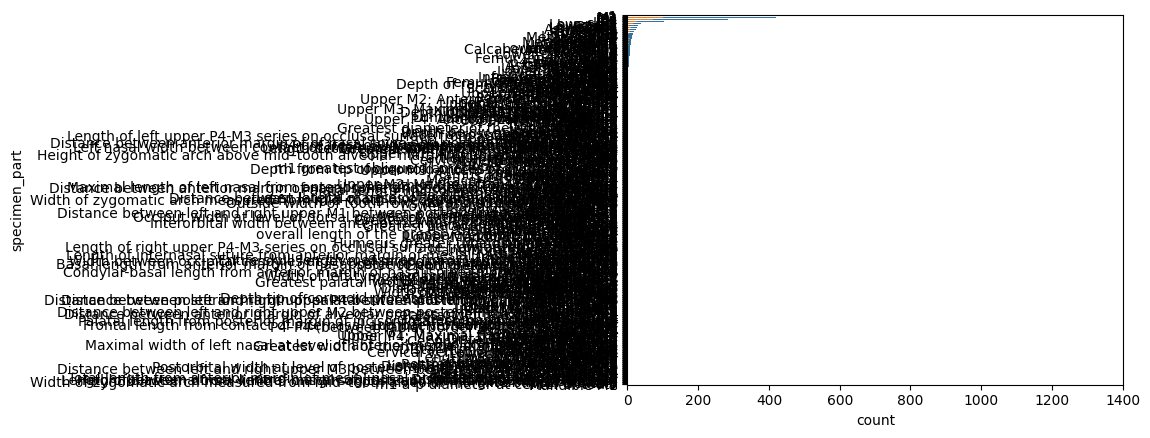

In [119]:
sns.countplot(train_df['specimen_part'], order = train_df['specimen_part'].value_counts().index)
sns.countplot(test_df['specimen_part'], order = test_df['specimen_part'].value_counts().index)
plt.savefig("../graphs/specimen_part_countplot.png", bbox_inches="tight")

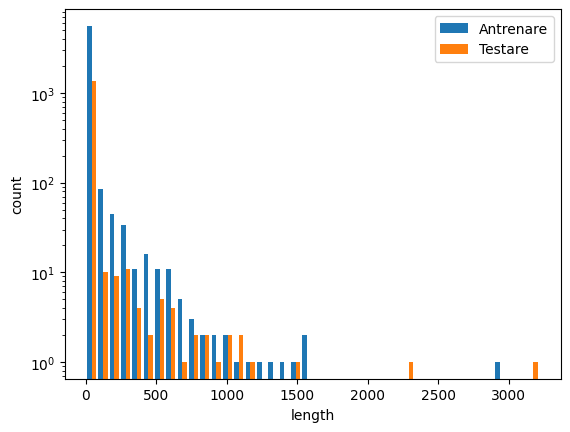

In [120]:
plt.hist([train_df['length'], test_df['length']], bins=40, log=True)
plt.legend(['Antrenare', 'Testare'])
plt.xlabel('length')
plt.ylabel('count')
plt.savefig("../graphs/length_histogram.png", bbox_inches="tight")

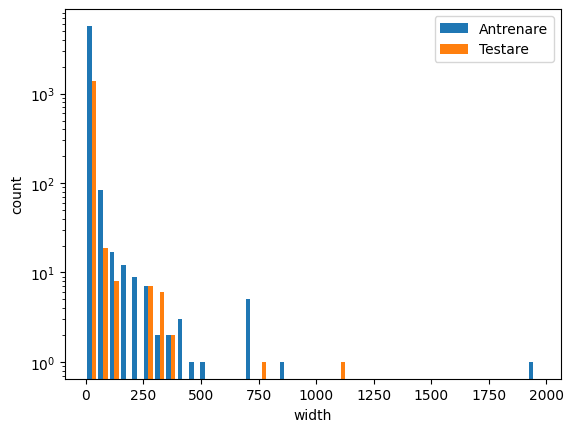

In [121]:
plt.hist([train_df['width'], test_df['width']], bins=40, log=True)
plt.legend(['Antrenare', 'Testare'])
plt.xlabel('width')
plt.ylabel('count')
plt.savefig("../graphs/width_histogram.png", bbox_inches="tight")

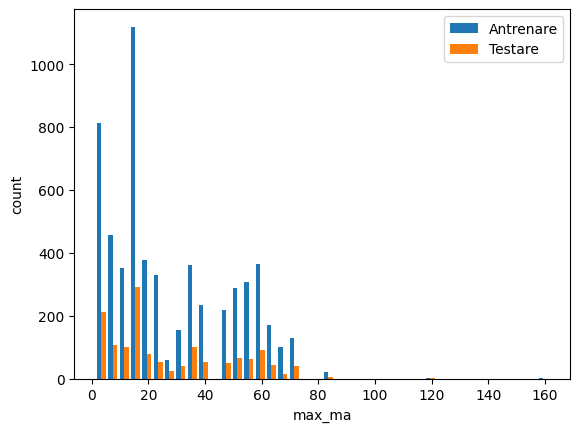

In [122]:
plt.hist([train_df['max_ma'], test_df['max_ma']], bins=40)
plt.legend(['Antrenare', 'Testare'])
plt.xlabel('max_ma')
plt.ylabel('count')
plt.savefig("../graphs/max_ma_histogram.png", bbox_inches="tight")

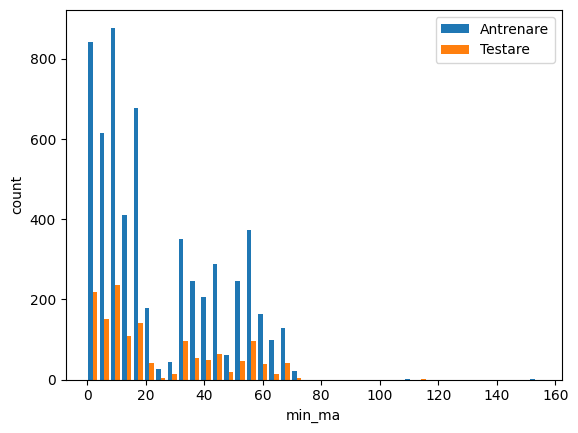

In [123]:
plt.hist([train_df['min_ma'], test_df['min_ma']], bins=40)
plt.legend(['Antrenare', 'Testare'])
plt.xlabel('min_ma')
plt.ylabel('count')
plt.savefig("../graphs/min_ma_histogram.png", bbox_inches="tight")

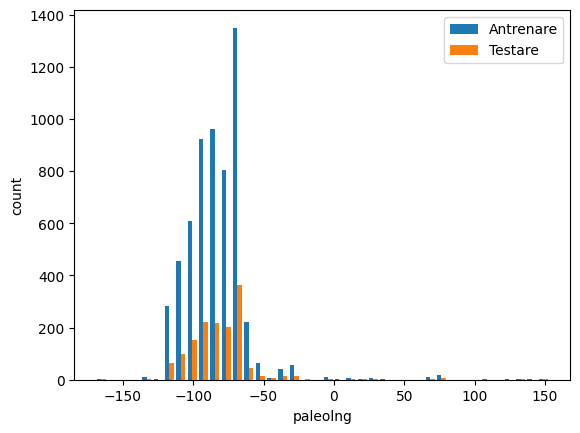

In [124]:
plt.hist([train_df['paleolng'], test_df['paleolng']], bins=40)
plt.legend(['Antrenare', 'Testare'])
plt.xlabel('paleolng')
plt.ylabel('count')
plt.savefig("../graphs/paleolng_histogram.png", bbox_inches="tight")

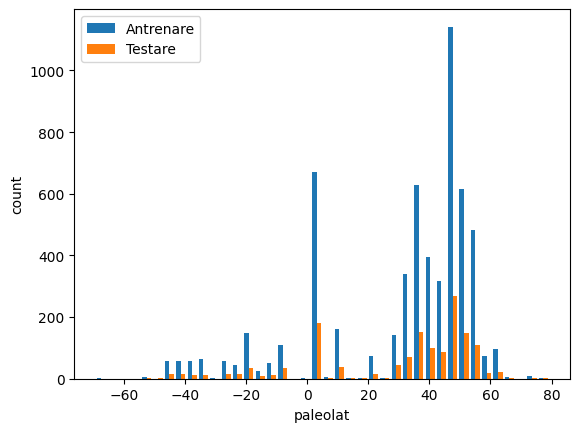

In [125]:
plt.hist([train_df['paleolat'], test_df['paleolat']], bins=40)
plt.legend(['Antrenare', 'Testare'])
plt.xlabel('paleolat')
plt.ylabel('count')
plt.savefig("../graphs/paleolat_histogram.png", bbox_inches="tight")

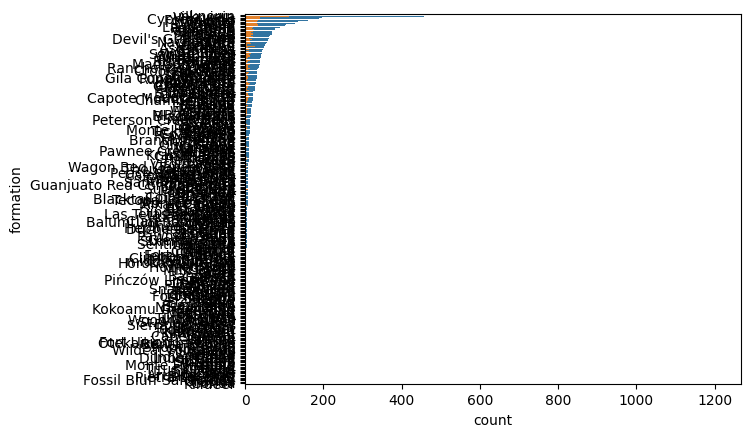

In [126]:
sns.countplot(train_df['formation'], order = train_df['formation'].value_counts().index)
sns.countplot(test_df['formation'], order = test_df['formation'].value_counts().index)
plt.savefig("../graphs/formation_countplot.png", bbox_inches="tight")

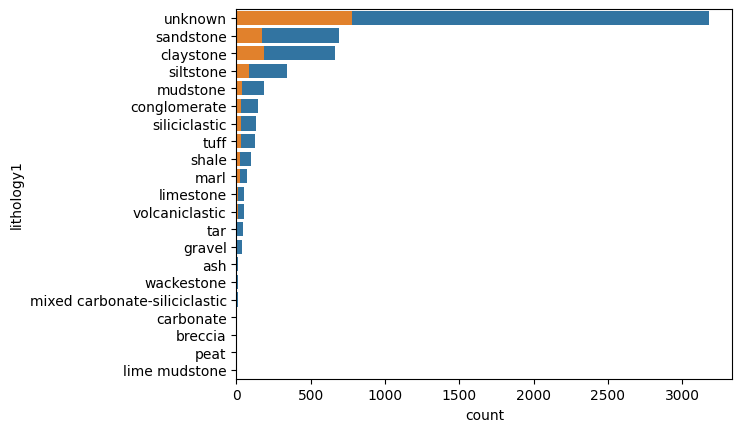

In [127]:
sns.countplot(train_df['lithology1'], order = train_df['lithology1'].value_counts().index)
sns.countplot(test_df['lithology1'], order = test_df['lithology1'].value_counts().index)
plt.savefig("../graphs/lithology1_countplot.png", bbox_inches="tight")

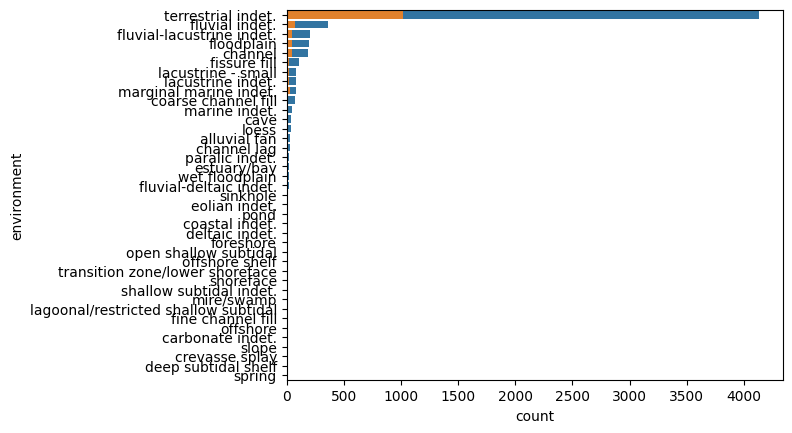

In [128]:
sns.countplot(train_df['environment'], order = train_df['environment'].value_counts().index)
sns.countplot(test_df['environment'], order = test_df['environment'].value_counts().index)
plt.savefig("../graphs/environment_countplot.png", bbox_inches="tight")

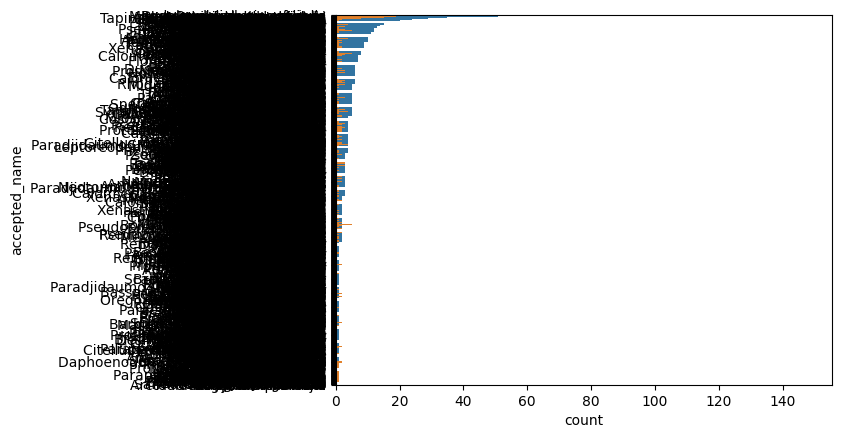

In [129]:
sns.countplot(train_df['accepted_name'], order = train_df['accepted_name'].value_counts().index)
sns.countplot(test_df['accepted_name'], order = test_df['accepted_name'].value_counts().index)
plt.savefig("../graphs/accepted_name_countplot.png", bbox_inches="tight")

#### Outlieri

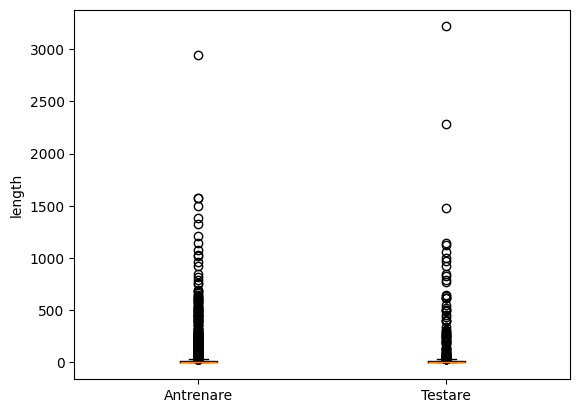

In [136]:
plt.boxplot([train_df['length'], test_df['length']], tick_labels=['Antrenare', 'Testare'])
plt.ylabel('length')
plt.savefig("../graphs/length_outliers.png", bbox_inches="tight")

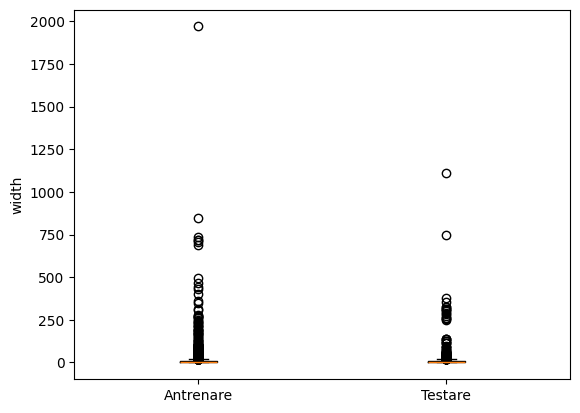

In [135]:
plt.boxplot([train_df['width'], test_df['width']], tick_labels=['Antrenare', 'Testare'])
plt.ylabel('width')
plt.savefig("../graphs/width_outliers.png", bbox_inches="tight")

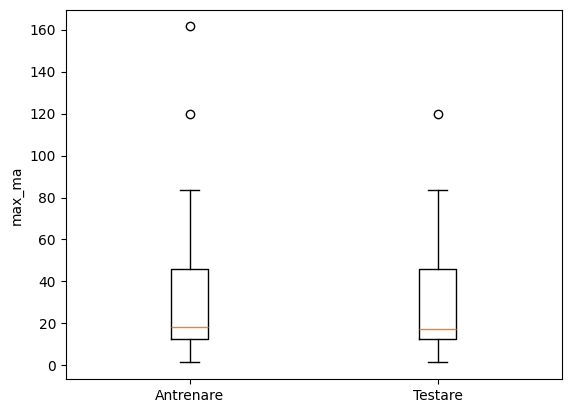

In [137]:
plt.boxplot([train_df['max_ma'], test_df['max_ma']], tick_labels=['Antrenare', 'Testare'])
plt.ylabel('max_ma')
plt.savefig("../graphs/max_ma_outliers.png", bbox_inches="tight")

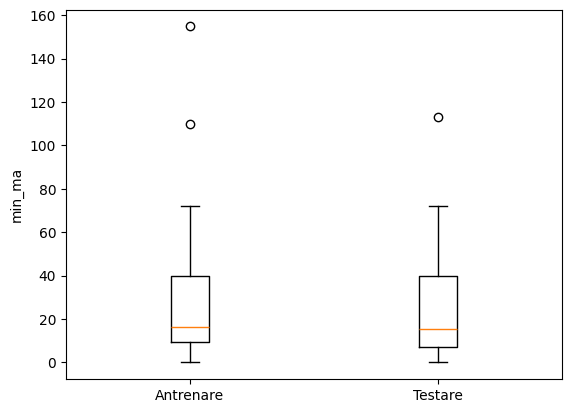

In [138]:
plt.boxplot([train_df['min_ma'], test_df['min_ma']], tick_labels=['Antrenare', 'Testare'])
plt.ylabel('min_ma')
plt.savefig("../graphs/min_ma_outliers.png", bbox_inches="tight")

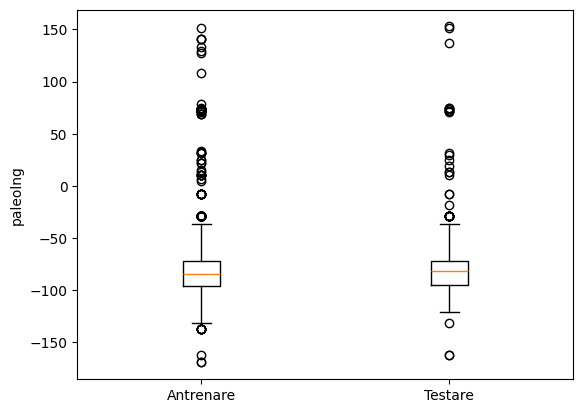

In [139]:
plt.boxplot([train_df['paleolng'], test_df['paleolng']], tick_labels=['Antrenare', 'Testare'])
plt.ylabel('paleolng')
plt.savefig("../graphs/paleolng_outliers.png", bbox_inches="tight")

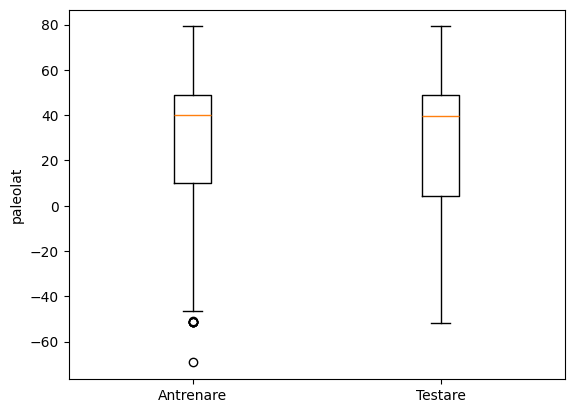

In [140]:
plt.boxplot([train_df['paleolat'], test_df['paleolat']], tick_labels=['Antrenare', 'Testare'])
plt.ylabel('paleolat')
plt.savefig("../graphs/paleolat_outliers.png", bbox_inches="tight")

#### Heatmaps

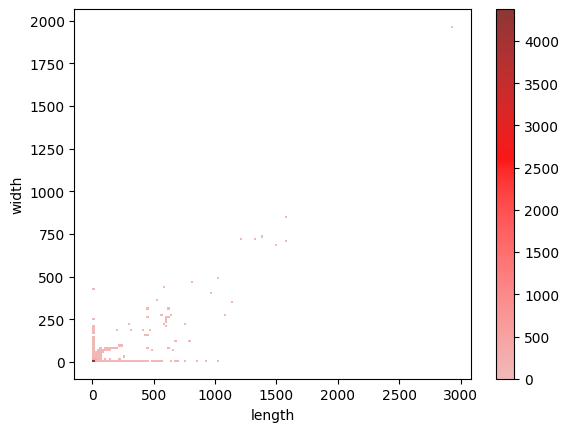

In [141]:
sns.histplot(train_df[['length', 'width']], x=train_df['length'], y=train_df['width'], cbar=True, color='red')
plt.savefig("../graphs/lw_heatmap.png", bbox_inches="tight")

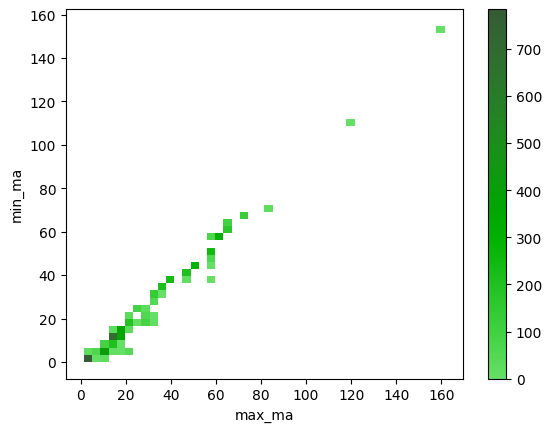

In [142]:
sns.histplot(train_df[['max_ma', 'min_ma']], x=train_df['max_ma'], y=train_df['min_ma'], cbar=True, color='green')
plt.savefig("../graphs/mm_heatmap.png", bbox_inches="tight")

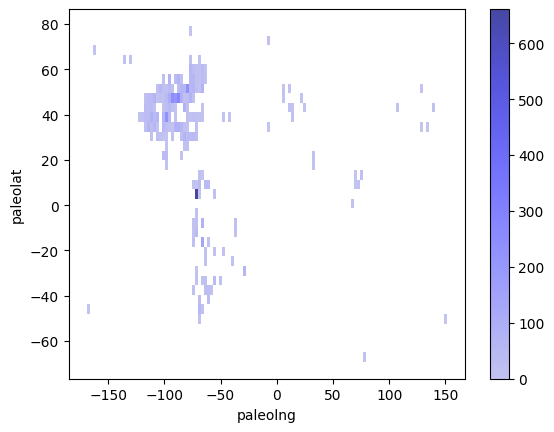

In [143]:
sns.histplot(train_df[['paleolng', 'paleolat']], x=train_df['paleolng'], y=train_df['paleolat'], cbar=True, color='blue')
plt.savefig("../graphs/pp_heatmap.png", bbox_inches="tight")

#### Relații cu variabila țintă

In [165]:
SAMPLE_SIZE = 200

/home/mihaigssh/an1s2/pclp3/venv/lib/python3.12/site-packages/seaborn/distributions.py:267: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  baselines[cols] = curves[cols].shift(1, axis=1).fillna(0)


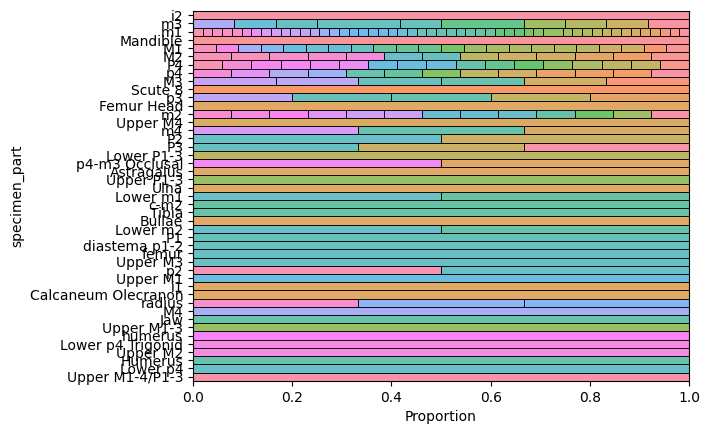

In [178]:
sns.histplot(train_df.sample(SAMPLE_SIZE, random_state=31), y='specimen_part', hue='accepted_name', multiple="fill", stat="proportion", discrete=True, legend=False)
plt.savefig("../graphs/specimen_part_histplot.png", bbox_inches="tight")

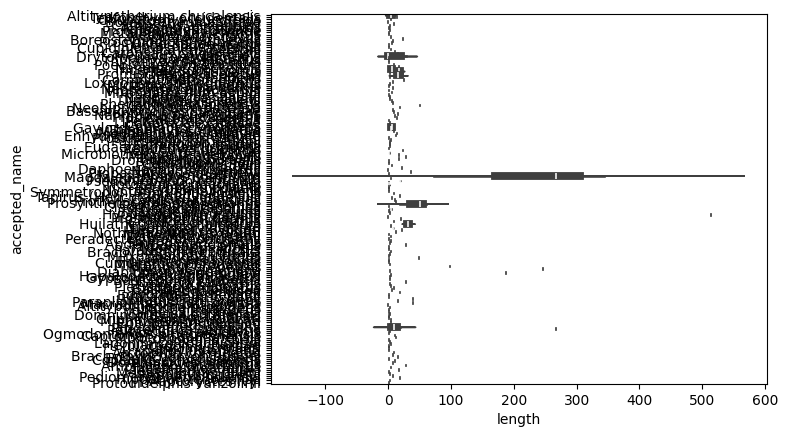

In [166]:
sns.violinplot(train_df.sample(SAMPLE_SIZE, random_state=31), x='length', y='accepted_name')
plt.savefig("../graphs/length_violinplot.png", bbox_inches="tight")

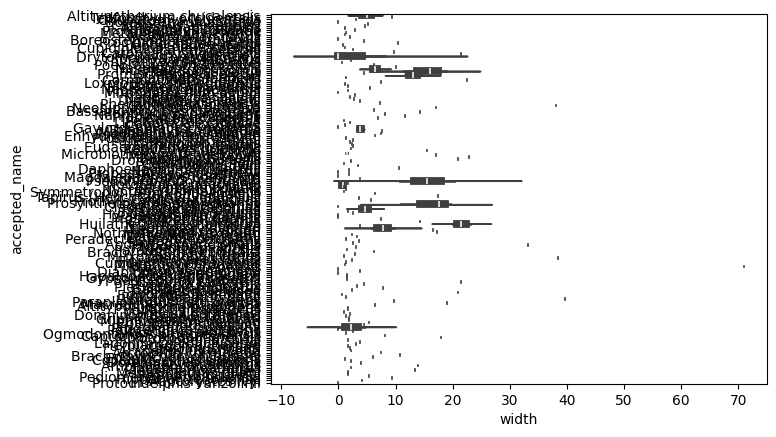

In [168]:
sns.violinplot(train_df.sample(SAMPLE_SIZE, random_state=31), x='width', y='accepted_name')
plt.savefig("../graphs/width_violinplot.png", bbox_inches="tight")

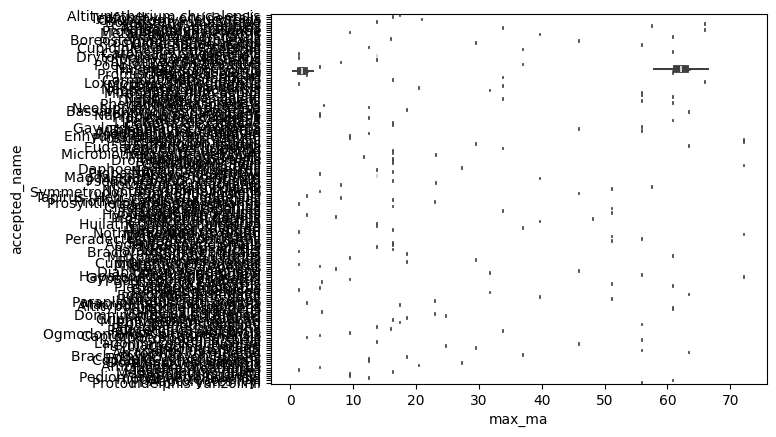

In [172]:
sns.violinplot(train_df.sample(SAMPLE_SIZE, random_state=31), x='max_ma', y='accepted_name')
plt.savefig("../graphs/max_ma_violinplot.png", bbox_inches="tight")

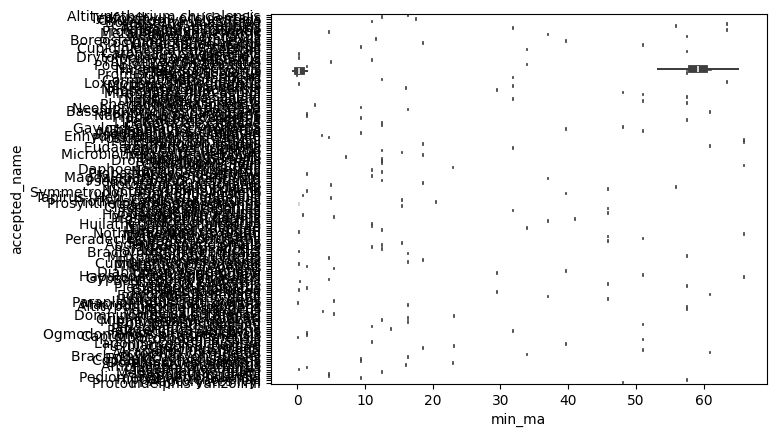

In [170]:
sns.violinplot(train_df.sample(SAMPLE_SIZE, random_state=31), x='min_ma', y='accepted_name')
plt.savefig("../graphs/min_ma_violinplot.png", bbox_inches="tight")

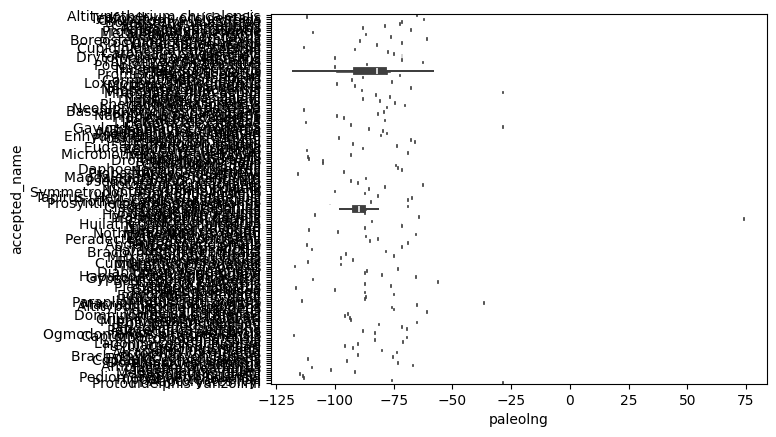

In [174]:
sns.violinplot(train_df.sample(SAMPLE_SIZE, random_state=31), x='paleolng', y='accepted_name')
plt.savefig("../graphs/paleolng_violinplot.png", bbox_inches="tight")

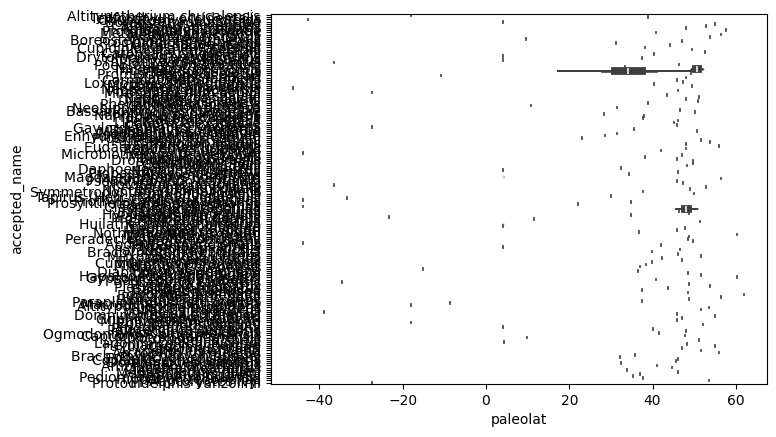

In [173]:
sns.violinplot(train_df.sample(SAMPLE_SIZE, random_state=31), x='paleolat', y='accepted_name')
plt.savefig("../graphs/paleolat_violinplot.png", bbox_inches="tight")

/home/mihaigssh/an1s2/pclp3/venv/lib/python3.12/site-packages/seaborn/distributions.py:267: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  baselines[cols] = curves[cols].shift(1, axis=1).fillna(0)


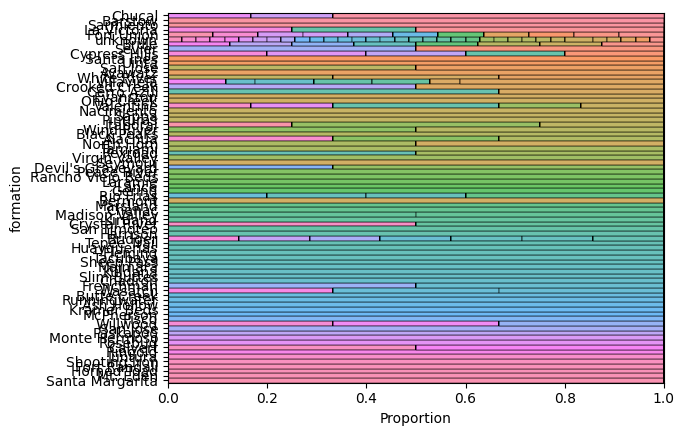

In [175]:
sns.histplot(train_df.sample(SAMPLE_SIZE, random_state=31), y='formation', hue='accepted_name', multiple='fill', stat='proportion', discrete=True, legend=False)
plt.savefig("../graphs/formation_histplot.png", bbox_inches="tight")

/home/mihaigssh/an1s2/pclp3/venv/lib/python3.12/site-packages/seaborn/distributions.py:267: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  baselines[cols] = curves[cols].shift(1, axis=1).fillna(0)


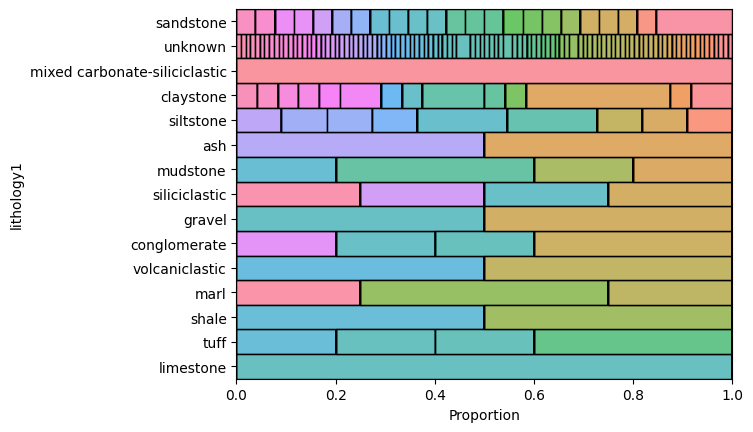

In [176]:
sns.histplot(train_df.sample(SAMPLE_SIZE, random_state=31), y='lithology1', hue='accepted_name', multiple='fill', stat='proportion', discrete=True, legend=False)
plt.savefig("../graphs/lithology1_histplot.png", bbox_inches="tight")

/home/mihaigssh/an1s2/pclp3/venv/lib/python3.12/site-packages/seaborn/distributions.py:267: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  baselines[cols] = curves[cols].shift(1, axis=1).fillna(0)


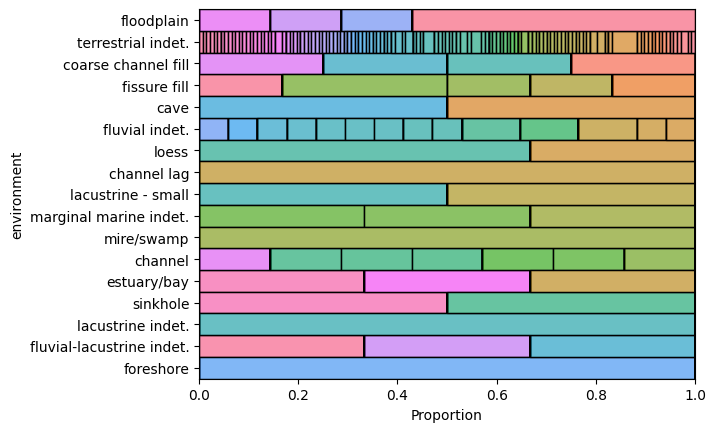

In [177]:
sns.histplot(train_df.sample(SAMPLE_SIZE, random_state=31), y='environment', hue='accepted_name', multiple="fill", stat="proportion", discrete=True, legend=False)
plt.savefig("../graphs/environment_histplot.png", bbox_inches="tight")